[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/doxav/astromodel_proving/blob/main/analysis/06_predictive_validation_and_perturbation.ipynb)

# Step 06 - Predictive validation and perturbation robustness

This notebook runs the local Step 06 pipeline without Google Drive dependencies and writes auditable outputs under `outputs/predictive_validation/`.

**Scope:** reviewer-facing validation uses all accepted cells by default (`candidate_policy='best_per_cell'`) and all six canonical currents for perturbations. This is a full cell-level validation scope: all accepted cells are represented by one best accepted candidate per cell, avoiding arbitrary candidate-row caps while preventing a candidate-rich cell from dominating the perturbation audit.

**Claim scope:** Step 06 may support a predictive/perturbation robustness screen, but it does not by itself authorize final biological degeneracy wording. Later assumption-sensitivity and parameter-plausibility steps remain required.

In [1]:
from pathlib import Path
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(os.environ.get("ASTROMODEL_PROJECT_ROOT", ".")).resolve()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
PROJECT_ROOT


PosixPath('/home/xav/code/astromodel_proving')

In [2]:
from src.step06_predictive_validation import Step06Config, run_step06_predictive_validation

config = Step06Config(
    max_candidates=None,
    candidate_policy="best_per_cell",
    time_points=50,
    perturbation_current_na=None,
    write_outputs=True,
)
result = run_step06_predictive_validation(PROJECT_ROOT, config)
result["analysis_summary"]

{'step_name': 'Step 06 — Predictive validation and perturbation robustness',
 'config': {'max_candidates': None,
  'step04_source_path': None,
  'candidate_policy': 'best_per_cell',
  'candidates_per_cell': 3,
  'time_points': 50,
  't_final_ms': 50000.0,
  'prediction_interval_quantiles': (0.05, 0.5, 0.95),
  'min_holdout_pass_fraction': 0.3,
  'max_trace_rmse_mV': 25.0,
  'perturbation_current_na': None,
  'perturbation_factors': {'nominal': 1.0,
   'eps_scale_low': 0.5,
   'eps_scale_high': 2.0,
   'stimulus_duration_short': 0.75,
   'stimulus_duration_long': 1.25,
   'baseline_K_o_low': 0.9,
   'baseline_K_o_high': 1.1,
   'current_scale_low': 0.75,
   'current_scale_high': 1.25},
  'robustness_recovery_error_max': 1.5,
  'robustness_peak_ratio_max': 1.75,
  'robustness_K_o_peak_max_mM': 15.0,
  'robustness_K_o_final_max_mM': 7.0,
  'min_perturbation_feature_pass_fraction': 0.25,
  'min_robust_fraction': 0.5,
  'write_outputs': True,
  'require_candidate_level_heldout': True,
  'fi

## Accepted ensemble and mechanism inventory

In [3]:
heldout = result["heldout_current_errors"]
heldout[["file_id", "region", "condition", "candidate_id", "mechanism_cluster"]].drop_duplicates().head(10)

,file_id,region,condition,candidate_id,mechanism_cluster
0,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__hybrid_optuna_087,M1
8,1_DH_2_CONTROL,DH,CONTROL,1_DH_2_CONTROL__hybrid_optuna_098,M1
16,1_VH_1_CONTROL,VH,CONTROL,1_VH_1_CONTROL__hybrid_optuna_004,M2
24,1_VH_2_CONTROL,VH,CONTROL,1_VH_2_CONTROL__hybrid_optuna_001,M2
32,2_DH_1_CONTROL,DH,CONTROL,2_DH_1_CONTROL__hybrid_optuna_096,M1
40,3_DH_1_CONTROL,DH,CONTROL,3_DH_1_CONTROL__hybrid_optuna_097,M1
48,3_DH_2_CONTROL,DH,CONTROL,3_DH_2_CONTROL__hybrid_optuna_098,M1
56,DH_1_CONTROL,DH,CONTROL,DH_1_CONTROL__hybrid_optuna_099,M1
64,DH_1_MFA,DH,MFA,DH_1_MFA__hybrid_optuna_057,M1
72,DH_1_MFA_BA,DH,MFA_BA,DH_1_MFA_BA__hybrid_optuna_094,M3


## Held-out-current error table

In [4]:
heldout.head(12)

,file_id,region,condition,candidate_id,sweep,current_na,split_strategy,heldout_trace_rmse_mV,heldout_weighted_feature_pass_fraction,holdout_status,prediction_status,prediction_pass,mechanism_cluster,mechanism_label_status
0,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__hybrid_optuna_087,1,50,leave_one_current_out,7.581329,0.359609,passed,predictive_pass,True,M1,step05_label_available
1,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__hybrid_optuna_087,2,75,leave_one_current_out,7.581329,0.359609,passed,predictive_pass,True,M1,step05_label_available
2,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__hybrid_optuna_087,3,100,leave_one_current_out,7.581329,0.359609,passed,predictive_pass,True,M1,step05_label_available
3,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__hybrid_optuna_087,4,125,leave_one_current_out,7.581329,0.359609,passed,predictive_pass,True,M1,step05_label_available
4,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__hybrid_optuna_087,5,150,leave_one_current_out,7.581329,0.359609,passed,predictive_pass,True,M1,step05_label_available
5,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__hybrid_optuna_087,6,175,leave_one_current_out,7.581329,0.359609,passed,predictive_pass,True,M1,step05_label_available
6,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__hybrid_optuna_087,-1,162,low_to_high,7.581329,0.359609,stress_test_screen,predictive_pass,True,M1,step05_label_available
7,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__hybrid_optuna_087,-1,62,high_to_low,7.581329,0.359609,stress_test_screen,predictive_pass,True,M1,step05_label_available
8,1_DH_2_CONTROL,DH,CONTROL,1_DH_2_CONTROL__hybrid_optuna_098,1,50,leave_one_current_out,13.982361,0.359340,passed,predictive_pass,True,M1,step05_label_available
9,1_DH_2_CONTROL,DH,CONTROL,1_DH_2_CONTROL__hybrid_optuna_098,2,75,leave_one_current_out,13.982361,0.359340,passed,predictive_pass,True,M1,step05_label_available


## Prediction interval table and figure

In [5]:
intervals = result["prediction_intervals"]
intervals.head(12)

,region,condition,sweep,current_na,feature,n_predictions,n_source_candidates,source_candidate_ids,pi_lower,pi_median,pi_upper,interval_quantiles
0,DH,CONTROL,1,50,decay_slope_mV_per_s,7,7,1_DH_1_CONTROL__hybrid_optuna_087;1_DH_2_CONTR...,0.170739,0.607610,0.607610,"0.05,0.5,0.95"
1,DH,CONTROL,1,50,decay_tau_s,7,7,1_DH_1_CONTROL__hybrid_optuna_087;1_DH_2_CONTR...,17.627408,17.627408,145.431926,"0.05,0.5,0.95"
2,DH,CONTROL,1,50,peak_depolarization_mV,7,7,1_DH_1_CONTROL__hybrid_optuna_087;1_DH_2_CONTR...,5.326229,10.710587,10.710587,"0.05,0.5,0.95"
3,DH,CONTROL,1,50,plateau_slope_mV_per_s,7,7,1_DH_1_CONTROL__hybrid_optuna_087;1_DH_2_CONTR...,-0.031163,-0.031163,0.069534,"0.05,0.5,0.95"
4,DH,CONTROL,1,50,return_slope_mV_per_s,7,7,1_DH_1_CONTROL__hybrid_optuna_087;1_DH_2_CONTR...,0.032339,0.127605,0.127605,"0.05,0.5,0.95"
5,DH,CONTROL,1,50,rise_slope_mV_per_s,7,7,1_DH_1_CONTROL__hybrid_optuna_087;1_DH_2_CONTR...,0.150894,0.150894,0.170130,"0.05,0.5,0.95"
6,DH,CONTROL,1,50,rise_tau_s,7,7,1_DH_1_CONTROL__hybrid_optuna_087;1_DH_2_CONTR...,31.431995,70.980796,70.980808,"0.05,0.5,0.95"
7,DH,CONTROL,1,50,stim_end_depolarization_mV,7,7,1_DH_1_CONTROL__hybrid_optuna_087;1_DH_2_CONTR...,4.781151,8.876719,8.876720,"0.05,0.5,0.95"
8,DH,CONTROL,1,50,undershoot_magnitude_mV,7,7,1_DH_1_CONTROL__hybrid_optuna_087;1_DH_2_CONTR...,0.000000,0.000000,0.000000,"0.05,0.5,0.95"
9,DH,CONTROL,2,75,decay_slope_mV_per_s,7,7,1_DH_1_CONTROL__hybrid_optuna_087;1_DH_2_CONTR...,0.215382,0.810620,0.810620,"0.05,0.5,0.95"


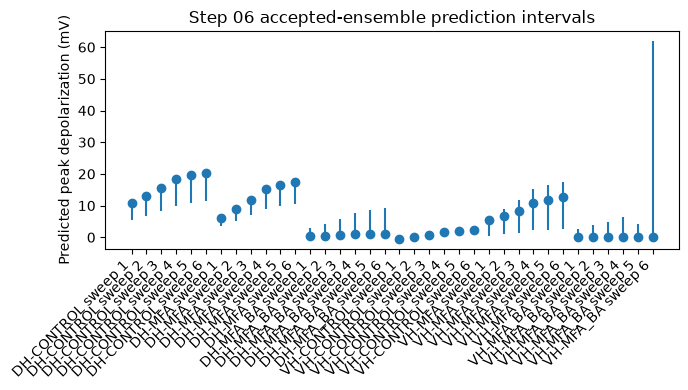

In [6]:
plot_df = intervals[intervals["feature"] == "peak_depolarization_mV"].copy()
fig, ax = plt.subplots(figsize=(7, 4))
if not plot_df.empty:
    labels = plot_df["region"].astype(str) + "-" + plot_df["condition"].astype(str) + " sweep " + plot_df["sweep"].astype(str)
    x = range(len(plot_df))
    ax.errorbar(x, plot_df["pi_median"], yerr=[plot_df["pi_median"] - plot_df["pi_lower"], plot_df["pi_upper"] - plot_df["pi_median"]], fmt="o")
    ax.set_xticks(list(x))
    ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_ylabel("Predicted peak depolarization (mV)")
ax.set_title("Step 06 accepted-ensemble prediction intervals")
fig.tight_layout()

## Feature posterior predictive coverage

In [7]:
ppc = result["feature_distribution_ppc"]
ppc.sort_values(["region", "condition", "sweep", "feature"]).head(15)

,region,condition,sweep,feature,n_predictions,empirical_lower,empirical_upper,coverage_fraction,reliability_weight,weighted_coverage,threshold_fallback
0,DH,CONTROL,1,decay_slope_mV_per_s,7,-0.919971,19.346905,1.000000,1.000000,1.000000,region_specific
1,DH,CONTROL,1,decay_tau_s,7,0.003572,0.606210,0.000000,1.000000,0.000000,region_specific
2,DH,CONTROL,1,peak_depolarization_mV,7,5.260867,9.464395,0.000000,0.500000,0.000000,region_specific
3,DH,CONTROL,1,plateau_slope_mV_per_s,7,-0.071938,0.044090,0.857143,1.000000,0.857143,region_specific
4,DH,CONTROL,1,return_slope_mV_per_s,7,0.026767,0.035590,0.000000,0.928571,0.000000,region_specific
5,DH,CONTROL,1,rise_slope_mV_per_s,7,-1.456547,15.727173,1.000000,1.000000,1.000000,region_specific
6,DH,CONTROL,1,rise_tau_s,7,-0.005953,0.740964,0.000000,1.000000,0.000000,region_specific
7,DH,CONTROL,1,stim_end_depolarization_mV,7,4.569925,9.574925,0.857143,0.500000,0.428571,region_specific
8,DH,CONTROL,1,undershoot_magnitude_mV,7,-0.684730,2.759430,1.000000,1.000000,1.000000,region_specific
9,DH,CONTROL,2,decay_slope_mV_per_s,7,-3.079960,29.092385,1.000000,1.000000,1.000000,region_specific


## Perturbation robustness

In [8]:
perturb = result["perturbation_sweeps"]
perturb_cols = [
    "file_id", "region", "condition", "mechanism_cluster", "buffering_phenotype",
    "current_na", "perturbation", "K_o_peak", "K_o_recovery_error",
    "Vm_feature_pass_fraction", "hidden_flux_plausible", "robust_under_perturbation",
    "perturbation_status", "simulation_status",
]
perturb[perturb_cols].head(30)

,file_id,region,condition,mechanism_cluster,buffering_phenotype,current_na,perturbation,K_o_peak,K_o_recovery_error,Vm_feature_pass_fraction,hidden_flux_plausible,robust_under_perturbation,perturbation_status,simulation_status
0,1_DH_1_CONTROL,DH,CONTROL,M1,mixed_local_spatial_buffering,50,nominal,6.399778,0.007583,0.555556,True,True,evaluated,ok
1,1_DH_1_CONTROL,DH,CONTROL,M1,mixed_local_spatial_buffering,50,eps_scale_low,6.399556,0.015146,0.555556,True,True,evaluated,ok
2,1_DH_1_CONTROL,DH,CONTROL,M1,mixed_local_spatial_buffering,50,eps_scale_high,6.399889,0.003794,0.555556,True,True,evaluated,ok
3,1_DH_1_CONTROL,DH,CONTROL,M1,mixed_local_spatial_buffering,50,stimulus_duration_short,6.399568,0.008215,0.555556,True,True,evaluated,ok
4,1_DH_1_CONTROL,DH,CONTROL,M1,mixed_local_spatial_buffering,50,stimulus_duration_long,6.399887,0.006684,0.555556,True,True,evaluated,ok
5,1_DH_1_CONTROL,DH,CONTROL,M1,mixed_local_spatial_buffering,50,baseline_K_o_low,6.399778,0.007581,0.555556,True,True,evaluated,ok
6,1_DH_1_CONTROL,DH,CONTROL,M1,mixed_local_spatial_buffering,50,baseline_K_o_high,6.399778,0.008837,0.555556,True,True,evaluated,ok
7,1_DH_1_CONTROL,DH,CONTROL,M1,mixed_local_spatial_buffering,50,current_scale_low,4.816832,0.009431,0.555556,True,True,evaluated,ok
8,1_DH_1_CONTROL,DH,CONTROL,M1,mixed_local_spatial_buffering,50,current_scale_high,7.999023,0.005676,0.444444,True,True,evaluated,ok
9,1_DH_1_CONTROL,DH,CONTROL,M1,mixed_local_spatial_buffering,75,nominal,7.229412,0.006596,0.555556,True,True,evaluated,ok


In [9]:
robustness = result["robustness_summary"]
robustness

,mechanism_cluster,region,condition,n_candidates,n_cells,holdout_pass_fraction,mean_weighted_ppc_coverage,perturbation_robust_fraction,perturbation_vm_feature_pass_fraction,hidden_flux_plausible_fraction,biological_description_score,buffering_phenotype_labels,step05_evidence_status,validation_label,step06_screen_claim,final_biological_degeneracy_claim_allowed,degeneracy_claim_allowed,claim_scope_after_step06
0,M1,DH,CONTROL,7,7,1.0,0.343915,0.708333,0.410053,1.0,0.692460,low_recruitment_local_storage;mixed_local_spat...,candidate_regime_screen,predictive_supported,candidate_regime_supported_by_step06_predictiv...,False,False,candidate_regime_supported_by_step06_predictiv...
1,M1,DH,MFA,2,2,1.0,0.430556,0.468750,0.452050,1.0,0.670271,kir_dominant_local_buffering;mixed_local_spati...,candidate_regime_screen,prediction_limited,mechanism_candidate_not_supported_by_step06_sc...,False,False,mechanism_candidate_not_supported_by_step06_sc...
2,M1,VH,MFA,2,2,1.0,0.179579,0.114583,0.259590,1.0,0.510751,kir_dominant_local_buffering;low_recruitment_l...,candidate_regime_screen,prediction_limited,mechanism_candidate_not_supported_by_step06_sc...,False,False,mechanism_candidate_not_supported_by_step06_sc...
3,M2,DH,MFA,4,4,1.0,0.430556,0.354167,0.563409,1.0,0.669626,available_surface_voltage_coupled_but_ionic_re...,candidate_regime_screen,prediction_limited,mechanism_candidate_not_supported_by_step06_sc...,False,False,mechanism_candidate_not_supported_by_step06_sc...
4,M2,VH,CONTROL,2,2,1.0,0.081481,0.000000,0.109954,1.0,0.438287,kir_dominant_local_buffering;mixed_local_spati...,candidate_regime_screen,prediction_limited,mechanism_candidate_not_supported_by_step06_sc...,False,False,mechanism_candidate_not_supported_by_step06_sc...
5,M2,VH,MFA,5,5,1.0,0.179579,0.145833,0.239947,1.0,0.513072,available_surface_voltage_coupled_but_ionic_re...,candidate_regime_screen,prediction_limited,mechanism_candidate_not_supported_by_step06_sc...,False,False,mechanism_candidate_not_supported_by_step06_sc...
6,M3,DH,MFA_BA,6,6,1.0,0.491855,1.000000,0.588735,1.0,0.816118,available_surface_voltage_coupled_but_ionic_re...,candidate_regime_screen,predictive_supported,candidate_regime_supported_by_step06_predictiv...,False,False,candidate_regime_supported_by_step06_predictiv...
7,M3,VH,MFA_BA,7,7,1.0,0.276014,0.511905,0.333510,1.0,0.624286,kir_dominant_local_buffering;low_recruitment_l...,candidate_regime_screen,predictive_supported,candidate_regime_supported_by_step06_predictiv...,False,False,candidate_regime_supported_by_step06_predictiv...


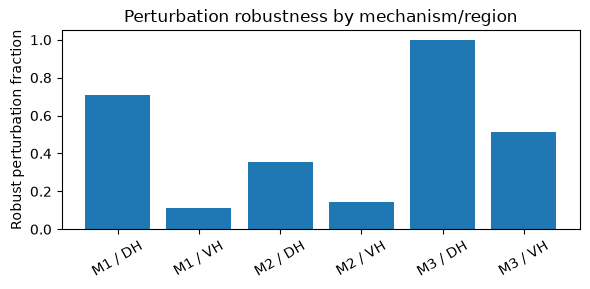

In [10]:
fig, ax = plt.subplots(figsize=(6, 3))
if not robustness.empty:
    robust_plot = robustness.copy()
    robust_plot["label"] = robust_plot["mechanism_cluster"].astype(str) + " / " + robust_plot["region"].astype(str)
    ax.bar(robust_plot["label"], robust_plot["perturbation_robust_fraction"].fillna(0.0))
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Robust perturbation fraction")
    ax.tick_params(axis="x", rotation=30)
ax.set_title("Perturbation robustness by mechanism/region")
fig.tight_layout()

## Claim scope after Step 06

The pipeline reports `predictive_supported`, `prediction_limited`, `fit_only`, or `insufficient_evidence`. It also reports a numerical `biological_description_score` that combines held-out, posterior predictive, perturbation, Vm-feature, and hidden-flux support. This score is an evidence-maturity screen, not a degeneracy claim by itself.

The notebook does **not** upgrade clusters to `candidate_degenerate_regimes` from Step 06 alone; any degeneracy wording requires mechanism distinction plus predictive/perturbation support and later assumption-sensitivity and parameter-plausibility checks.

In [11]:
pd.DataFrame([result["analysis_summary"]])

,step_name,config,n_candidates,n_heldout_rows,n_prediction_interval_rows,n_ppc_rows,n_perturbation_rows,validation_labels,headline_claim_scope,elapsed_seconds
0,Step 06 — Predictive validation and perturbati...,"{'max_candidates': None, 'step04_source_path':...",35,280,324,324,1890,"[prediction_limited, predictive_supported]",Mechanism regimes require predictive_supported...,96.910872


In [12]:
assert set(perturb["current_na"].dropna().astype(int)) == {50, 75, 100, 125, 150, 175}
duration = perturb[perturb["perturbation"].astype(str).str.startswith("stimulus_duration")]
assert not duration.empty
assert duration["perturbation_status"].eq("evaluated").all()
assert "biological_description_score" in robustness.columns
assert not robustness["final_biological_degeneracy_claim_allowed"].astype(bool).any()
print("Step 06 full-current validation notebook completed across the full cell-level target scope.")

Step 06 full-current validation notebook completed across the full cell-level target scope.


## Candidate-scope sensitivity

This sensitivity screen compares the default best-per-cell Step 06 validation against top-k, mechanism-cluster-diverse, and continuous mechanism-score-diverse accepted representatives per cell. The mechanism-score-diverse policy is shown as a diagnostic/negative-control sensitivity, not as a competing recommended policy: it tests whether selecting by log effective coordinates plus Step 05 continuous scores improves Step 06 support. Two paired plots are shown below: the first preserves the previous headline policy set, and the second adds the mechanism-score diagnostic row.


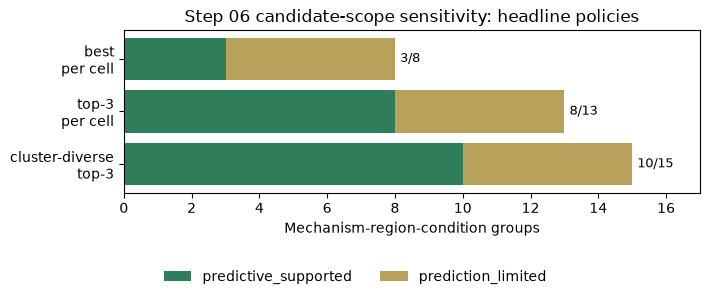

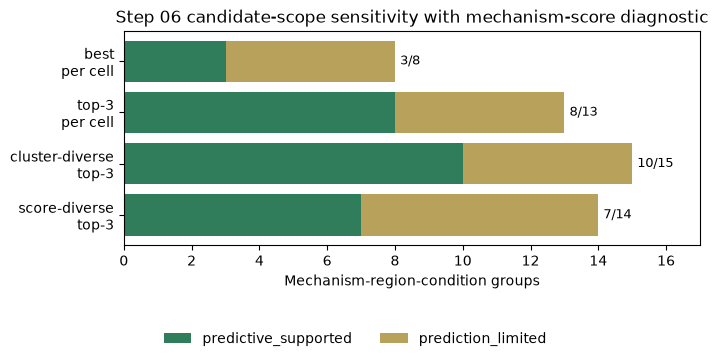

,candidate_policy,analysis_role,headline_use,n_candidates,n_robustness_rows,n_predictive_supported_rows,n_prediction_limited_rows,predictive_supported_fraction,mean_biological_description_score,mean_perturbation_robust_fraction
0,best_per_cell,canonical conservative default,True,35,8,3,5,0.375000,0.616766,0.412946
1,top_k_per_cell,expanded-scope sensitivity,True,99,13,8,5,0.615385,0.648092,0.522765
2,mechanism_diverse_per_cell,recommended expanded-scope sensitivity,True,84,15,10,5,0.666667,0.664647,0.556845
3,mechanism_score_diverse_per_cell,diagnostic negative-control sensitivity,False,99,14,7,7,0.500000,0.643710,0.504473


In [14]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path(os.environ.get("ASTROMODEL_PROJECT_ROOT", ".")).resolve()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.step06_predictive_validation import (
    Step06Config,
    load_step06_inputs,
    run_step06_predictive_validation,
)

scope_rows = []
scope_robustness_tables = []
policy_descriptions = {
    "best_per_cell": "one highest-quality accepted candidate per represented cell",
    "top_k_per_cell": "top accepted candidates per cell by heldout/fit quality",
    "mechanism_diverse_per_cell": "one accepted candidate per Step 05 mechanism cluster per cell, up to k",
    "mechanism_score_diverse_per_cell": "quality-seeded maximin selection over log effective coordinates plus Step 05 continuous mechanism scores",
}
policy_roles = {
    "best_per_cell": "canonical conservative default",
    "top_k_per_cell": "expanded-scope sensitivity",
    "mechanism_diverse_per_cell": "recommended expanded-scope sensitivity",
    "mechanism_score_diverse_per_cell": "diagnostic negative-control sensitivity",
}
policy_order = [
    ("best_per_cell", 1),
    ("top_k_per_cell", 3),
    ("mechanism_diverse_per_cell", 3),
    ("mechanism_score_diverse_per_cell", 3),
]
for candidate_policy, candidates_per_cell in policy_order:
    scope_config = Step06Config(
        max_candidates=None,
        candidate_policy=candidate_policy,
        candidates_per_cell=candidates_per_cell,
        time_points=50,
        perturbation_current_na=None,
        write_outputs=False,
    )
    scope_candidates, _ = load_step06_inputs(PROJECT_ROOT, scope_config)
    scope_result = run_step06_predictive_validation(PROJECT_ROOT, scope_config)
    scope_robustness = scope_result["robustness_summary"].copy()
    scope_robustness.insert(0, "candidate_policy", candidate_policy)
    scope_robustness.insert(1, "candidates_per_cell", candidates_per_cell)
    scope_robustness.insert(2, "analysis_role", policy_roles[candidate_policy])
    scope_robustness_tables.append(scope_robustness)
    supported_rows = int((scope_robustness["validation_label"].astype(str) == "predictive_supported").sum())
    limited_rows = int((scope_robustness["validation_label"].astype(str) == "prediction_limited").sum())
    robustness_rows = int(len(scope_robustness))
    scope_rows.append({
        "candidate_policy": candidate_policy,
        "candidates_per_cell": candidates_per_cell,
        "analysis_role": policy_roles[candidate_policy],
        "headline_use": candidate_policy != "mechanism_score_diverse_per_cell",
        "selection_basis": policy_descriptions[candidate_policy],
        "n_candidates": int(len(scope_candidates)),
        "n_cells": int(scope_candidates["file_id"].nunique()),
        "n_robustness_rows": robustness_rows,
        "n_predictive_supported_rows": supported_rows,
        "n_prediction_limited_rows": limited_rows,
        "predictive_supported_fraction": supported_rows / robustness_rows if robustness_rows else float("nan"),
        "mean_biological_description_score": float(pd.to_numeric(scope_robustness["biological_description_score"], errors="coerce").mean()),
        "mean_perturbation_robust_fraction": float(pd.to_numeric(scope_robustness["perturbation_robust_fraction"], errors="coerce").mean()),
    })

scope_sensitivity_summary = pd.DataFrame(scope_rows)
scope_sensitivity_robustness = pd.concat(scope_robustness_tables, ignore_index=True, sort=False)
reviewer_synthesis_dir = PROJECT_ROOT / "outputs" / "reviewer_synthesis"
reviewer_synthesis_dir.mkdir(parents=True, exist_ok=True)
scope_sensitivity_summary.to_csv(reviewer_synthesis_dir / "step06_candidate_scope_sensitivity_summary.csv", index=False)
scope_sensitivity_robustness.to_csv(reviewer_synthesis_dir / "step06_candidate_scope_sensitivity_robustness.csv", index=False)

plot_labels = {
    "best_per_cell": "best\nper cell",
    "top_k_per_cell": "top-3\nper cell",
    "mechanism_diverse_per_cell": "cluster-diverse\ntop-3",
    "mechanism_score_diverse_per_cell": "score-diverse\ntop-3",
}

def plot_scope_support(plot_df: pd.DataFrame, title: str, filename: str) -> None:
    ordered = plot_df.copy().reset_index(drop=True)
    y = list(range(len(ordered)))
    fig, ax = plt.subplots(figsize=(7.2, max(2.7, 0.62 * len(ordered) + 1.2)))
    supported = ordered["n_predictive_supported_rows"].to_numpy(dtype=float)
    limited = ordered["n_prediction_limited_rows"].to_numpy(dtype=float)
    ax.barh(y, supported, color="#2f7d5b", label="predictive_supported")
    ax.barh(y, limited, left=supported, color="#b8a15a", label="prediction_limited")
    ax.set_yticks(y)
    ax.set_yticklabels([plot_labels[p] for p in ordered["candidate_policy"]])
    ax.invert_yaxis()
    ax.set_xlabel("Mechanism-region-condition groups")
    ax.set_title(title)
    for idx, row in ordered.iterrows():
        total = int(row["n_robustness_rows"])
        supported_n = int(row["n_predictive_supported_rows"])
        ax.text(total + 0.15, idx, f"{supported_n}/{total}", va="center", fontsize=9)
    ax.set_xlim(0, max(ordered["n_robustness_rows"].max() + 2, 5))
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0.01), ncol=2, frameon=False)
    fig.tight_layout(rect=(0, 0.16, 1, 1))
    fig.savefig(reviewer_synthesis_dir / filename, dpi=200, bbox_inches="tight")
    plt.show()

headline_scope = scope_sensitivity_summary[scope_sensitivity_summary["headline_use"]].copy()
plot_scope_support(
    headline_scope,
    "Step 06 candidate-scope sensitivity: headline policies",
    "step06_candidate_scope_sensitivity_headline_policies.png",
)
plot_scope_support(
    scope_sensitivity_summary,
    "Step 06 candidate-scope sensitivity with mechanism-score diagnostic",
    "step06_candidate_scope_sensitivity_with_mechanism_score.png",
)

display_cols = [
    "candidate_policy",
    "analysis_role",
    "headline_use",
    "n_candidates",
    "n_robustness_rows",
    "n_predictive_supported_rows",
    "n_prediction_limited_rows",
    "predictive_supported_fraction",
    "mean_biological_description_score",
    "mean_perturbation_robust_fraction",
]
scope_sensitivity_summary[display_cols]


## Post-execution scientific status

Executed status for reviewer response: Step 06 used one best accepted candidate per represented cell (35 candidates) and evaluated all six canonical currents, producing 280 held-out rows and 1890 perturbation rows. In the canonical best-per-cell screen, 3/8 mechanism-region-condition groups are `predictive_supported` and 5/8 remain `prediction_limited`.

Candidate-scope sensitivity now displays `mechanism_score_diverse_per_cell` as an explicit diagnostic rather than as a competing recommended policy. The headline policy set remains best-per-cell, top-3 per cell, and mechanism-cluster-diverse top-3; the paired diagnostic plot then adds mechanism-score-diverse top-3. Results show that top-3 per cell gives 8/13 supported rows, mechanism-cluster-diverse top-3 gives 10/15 supported rows, and mechanism-score-diverse top-3 gives 7/14 supported rows. This supports the design choice: Step 05 continuous mechanism scores are useful to audit selection, but the existing mechanism-cluster-diverse policy remains the stronger expanded-scope result.

Claim progression: R6 and part of R5 are strengthened by showing that candidate diversity improves predictive/perturbation support and by explicitly testing the continuous-score novelty alternative. The diagnostic policy does not upgrade final biological degeneracy wording. Final degeneracy claims remain prohibited because support is not uniform and assumption/parameter checks still constrain the claim.
